# Heart Disease Prediction using XGBoost

## Problem Statement

Heart disease is one of the leading causes of death around the world.
Early prediction and diagnosis can help reduce the risk of death.

This is part one of our project where we are using a traditonal model to predict heart disease using data collected ata doctors office.

## Dataset Description

The dataset contains medical attributes of patients used to predict 
the presence of heart disease.



The target variable indicates whether the patient has heart disease or not.


It is worth noting that the Test.csv file does not have gt labels and is only used for inference. Because of this we have to split the train.csv up into a training and test split

In [12]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [14]:
df = pd.read_csv("train.csv")
df.head()


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [15]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [16]:
df.isnull().sum()


id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [17]:
df.describe()


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


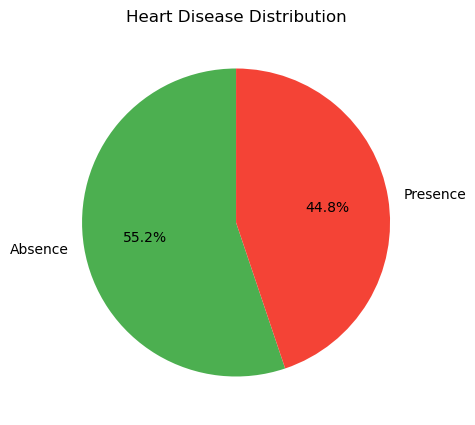

In [18]:
counts = df["Heart Disease"].value_counts()
labels = ["Absence", "Presence"]
colors = ["#4CAF50", "#F44336"]

plt.figure(figsize=(5, 5))
plt.pie(counts, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
plt.title("Heart Disease Distribution")
plt.show()

In [19]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Presence": 1,
    "Absence": 0
})


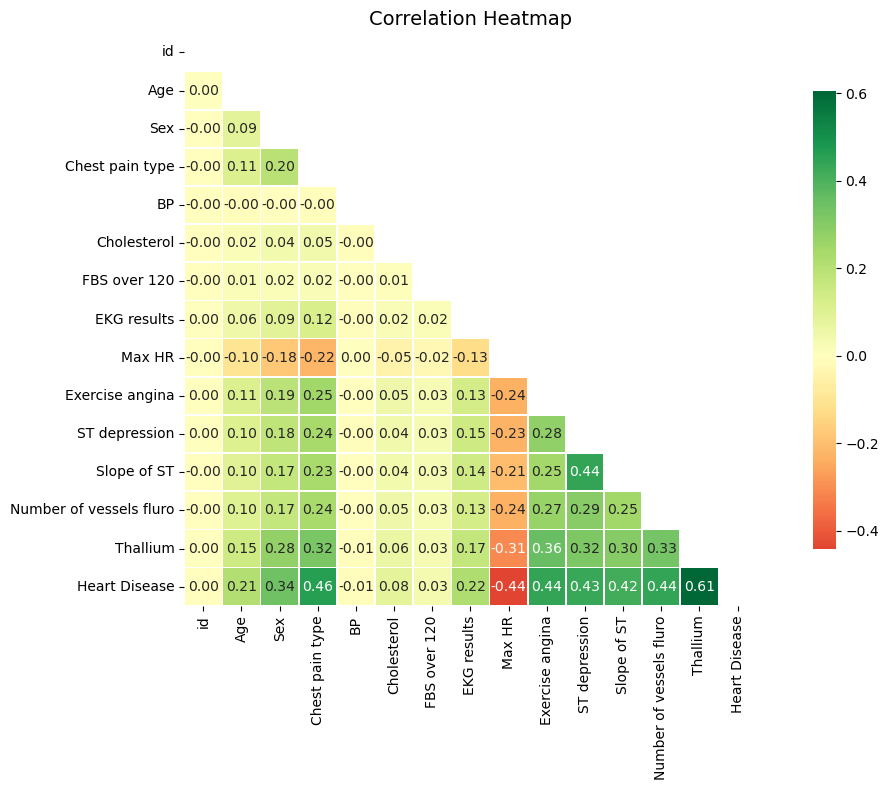

In [20]:
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0,
            linewidths=0.5, linecolor="white",
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=50,
)


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## XGBoost Model Training


In [24]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train_scaled, y_train)


C:\Users\matts\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [13:29:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
y_pred = model.predict(X_test_scaled)


In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)


XGBoost Accuracy: 0.8872460317460318


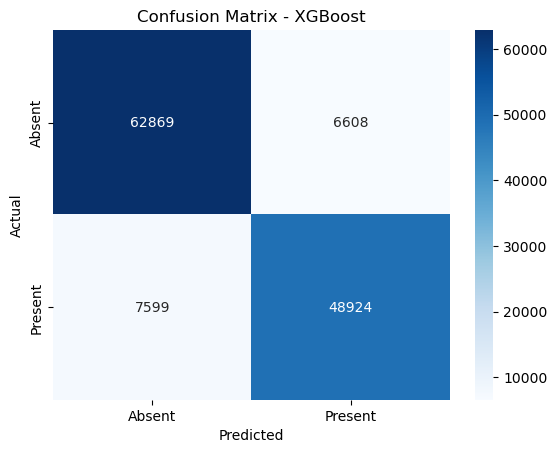

In [27]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Absent", "Present"],
            yticklabels=["Absent", "Present"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [28]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.90      0.90     69477
           1       0.88      0.87      0.87     56523

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



## Feature Importance


<Figure size 1000x600 with 0 Axes>

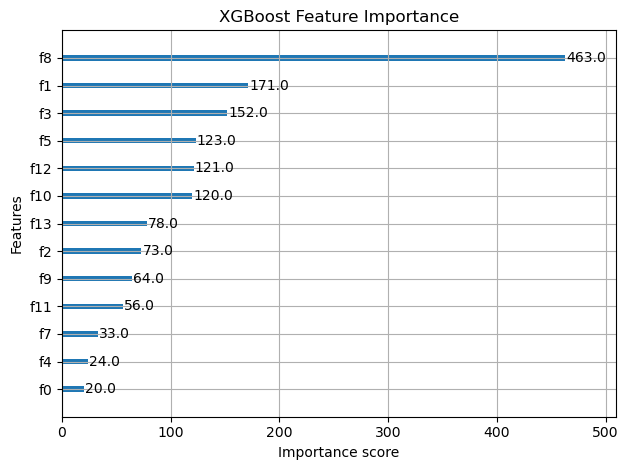

In [29]:
from xgboost import plot_importance
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=13)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

new_patient = pd.DataFrame([[
    1,    # id (just use any dummy number)
    70,   # Age
    1,    # Sex
    4,    # Chest pain type
    130,  # BP
    322,  # Cholesterol
    0,    # FBS over 120
    2,    # EKG results
    109,  # Max HR
    0,    # Exercise angina
    2.4,  # ST depression
    2,    # Slope of ST
    3,    # Number of vessels fluro
    3     # Thallium
]], columns=['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
             'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
             'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'])

new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)

print("--- Prediction Result ---")
if prediction[0] == 1:
    print("  Heart Disease: PRESENT")
else:
    print("  Heart Disease: ABSENT")


--- Prediction Result ---
❤️  Heart Disease: PRESENT


In [ ]:
import pandas as pd

new_patient = pd.DataFrame([[
    2,    # id (dummy)
    45,   # Age
    0,    # Sex (female)
    4,    # Chest pain type
    130,  # BP
    210,  # Cholesterol
    0,    # FBS over 120
    0,    # EKG results
    170,  # Max HR
    1,    # Exercise angina
    0.5,  # ST depression
    1,    # Slope of ST
    0,    # Number of vessels fluro
    5     # Thallium
]], columns=['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
             'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
             'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'])

new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)

print("--- Prediction Result ---")
if prediction[0] == 1:
    print("Heart Disease: PRESENT")
else:
    print( "Heart Disease: ABSENT")


--- Prediction Result ---
💚  Heart Disease: ABSENT


## Predictions on test.csv


In [40]:
# Load test data
df_test = pd.read_csv("test.csv")
print("Test set shape:", df_test.shape)
df_test.head()


Test set shape: (270000, 14)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [50]:
# Encode target if present in test set
X_test_new = df_test
y_test_new = None


In [51]:
# Scale and predict
X_test_new_scaled = scaler.transform(X_test_new)
test_preds = model.predict(X_test_new_scaled)
test_probs = model.predict_proba(X_test_new_scaled)[:, 1]

# Save predictions to CSV
output_df = X_test_new.copy()
output_df["Predicted Heart Disease"] = ["Presence" if p == 1 else "Absence" for p in test_preds]
output_df["Confidence (%)"] = (test_probs * 100).round(1)
output_df.to_csv("test_predictions.csv", index=False)
print("Predictions saved to test_predictions.csv")
output_df.head()


Predictions saved to test_predictions.csv


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Predicted Heart Disease,Confidence (%)
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3,Presence,90.099998
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3,Absence,0.900000
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7,Presence,97.599998
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3,Absence,0.600000
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7,Absence,26.799999


## Dataset Credit
Dataset: Heart Disease Prediction Using Machine Learning  
Author: Muhammad Shahzad  
Source: Kaggle  
License: CC BY-SA 4.0